# 宠物真实生活图像分类

来自 [AI for Beginners Curriculum](https://github.com/microsoft/ai-for-beginners) 的实验任务。

现在是时候处理一个更具挑战性的任务了——对原始的 [Oxford-IIIT 数据集](https://www.robots.ox.ac.uk/~vgg/data/pets/) 进行分类。让我们从加载和可视化数据集开始吧。


In [ ]:
import torch.utils.data
from sympy.core.random import shuffle
# from torch.ao.nn.quantized import ReLU6
# from torch.nn import Linear
# from torchtext.vocab import pretrained_aliases


我们将定义通用函数以从列表中显示一系列图像：


In [2]:
import matplotlib.pyplot as plt
import os
from PIL import Image
import numpy as np

def display_images(l,titles=None,fontsize=12):
    n=len(l)
    fig,ax = plt.subplots(1,n)
    for i,im in enumerate(l):
        ax[i].imshow(im)
        ax[i].axis('off')
        if titles is not None:
            print("!")
            ax[i].set_title(titles[i],fontsize=fontsize)
    fig.set_size_inches(fig.get_size_inches()*n)
    plt.tight_layout()
    plt.show()

您可以看到所有图像都位于一个名为`images`的目录中，并且它们的名称包含类别（品种）的名称：


In [5]:
fnames = os.listdir('images')[:5]
display_images([Image.open(os.path.join('images',x)) for x in fnames],titles=fnames,fontsize=30)

FileNotFoundError: [Errno 2] No such file or directory: 'images'

为了简化分类并使用与上一部分相同的方法加载图像，让我们将所有图像排序到相应的目录中：


In [ ]:
for fn in os.listdir('images'):
    cls = fn[:fn.rfind('_')].lower()
    os.makedirs(os.path.join('images',cls),exist_ok=True)
    os.replace(os.path.join('images',fn),os.path.join('images',cls,fn))

让我们也定义数据集中的类别数量：


In [3]:
num_classes = len(os.listdir('../petfaces'))
num_classes

37

## 为深度学习准备数据集

在开始训练我们的神经网络之前，我们需要将所有图像转换为张量，同时创建与标签（类别编号）对应的张量。大多数神经网络框架都提供了处理图像的简单工具：
* 在 Tensorflow 中，可以使用 `tf.keras.preprocessing.image_dataset_from_directory`
* 在 PyTorch 中，可以使用 `torchvision.datasets.ImageFolder`

正如你从上面的图片中看到的那样，所有图片的比例都接近正方形，因此我们需要将所有图像调整为正方形尺寸。此外，我们还可以将图像组织成小批量数据。


In [4]:
# PREPARE THE DATASET
from torchvision.datasets import ImageFolder
root="../petfaces"
Dataset=ImageFolder(root)

现在我们需要将数据集分为训练集和测试集：


In [18]:
# SPLIT INTO TRAIN-TEST DATASETS
import torch
train_size=int(0.8*len(Dataset))
test_size=len(Dataset)-train_size
trainData,testData=torch.utils.data.random_split(Dataset,[train_size,test_size])

现在定义数据加载器：


In [55]:
# DEFINE DATA LOADERS if needed
from torch.utils.data.dataloader import DataLoader
import torchvision.transforms as transforms
train_transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
test_transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])
])
trainData.dataset.transform=train_transform

testData.dataset.transform=test_transform

train_loader=DataLoader(trainData,shuffle=True,batch_size=64)
test_loader=DataLoader(testData,shuffle=False,batch_size=64)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.8039216].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.8901961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96862745].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.99215686..0.9764706].
Clipping input da

!
!
!
!
!
!
!
!
!
!


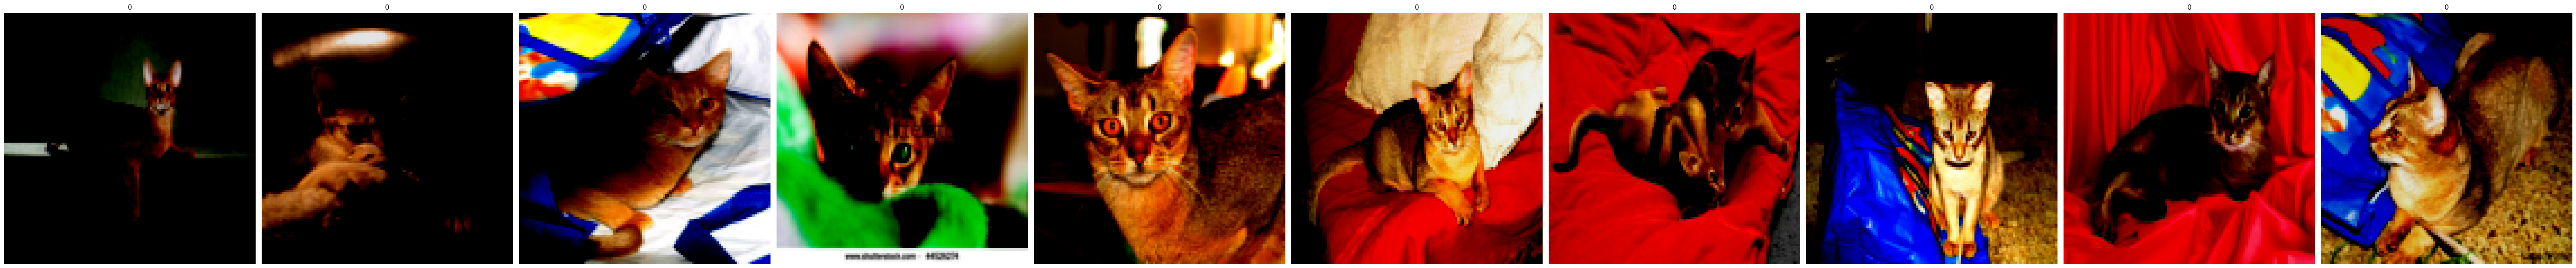

In [20]:
# [OPTIONAL] Plot the dataset
titles=[Dataset[i][1]  for i in range(10)]
display_images([Dataset[i][0].permute(1, 2, 0).numpy()  for i in range(10)],titles=titles)


## 定义一个神经网络

对于图像分类，你可能需要定义一个具有多层的卷积神经网络。需要注意以下几点：
* 牢记金字塔结构，也就是说，随着网络加深，滤波器的数量应该增加。
* 不要忘记在层之间添加激活函数（如 ReLU）和最大池化（Max Pooling）。
* 最终的分类器可以有隐藏层，也可以没有，但输出神经元的数量应该等于类别的数量。

一个重要的点是要正确设置最后一层的激活函数和损失函数：
* 在 Tensorflow 中，你可以使用 `softmax` 作为激活函数，并使用 `sparse_categorical_crossentropy` 作为损失函数。稀疏分类交叉熵和非稀疏的区别在于，前者期望输出为类别编号，而不是 one-hot 向量。
* 在 PyTorch 中，最后一层可以不使用激活函数，直接使用 `CrossEntropyLoss` 作为损失函数。这个函数会自动应用 softmax。

> **提示：** 在 PyTorch 中，你可以使用 `LazyLinear` 层代替 `Linear`，以避免手动计算输入的数量。它只需要一个 `n_out` 参数，即该层的神经元数量，输入数据的维度会在第一次 `forward` 传递时自动确定。


In [11]:
# DEFINE NEURAL NETWORK ARCHITECTURE

## 训练神经网络

现在我们可以开始训练神经网络了。在训练过程中，请在每个训练周期收集训练数据和测试数据的准确率，然后绘制准确率图表，以观察是否存在过拟合现象。


In [1]:
# TRAIN THE NEURAL NETWORK

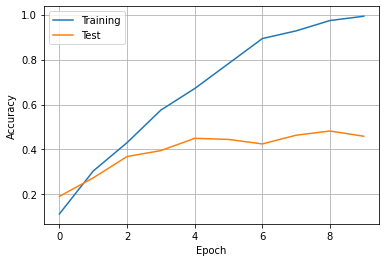

In [12]:
# PLOT THE RESULT: Train and Test Accuracy

## 迁移学习

为了提高准确率，我们可以使用预训练的神经网络作为特征提取器。可以尝试使用 VGG-16/VGG-19 模型、ResNet50 等。

> 由于这种训练速度较慢，可以先尝试用较少的训练轮次（例如 3 轮）来训练模型。如果需要进一步提高准确率，可以随时继续训练。

在迁移学习中，我们需要以不同的方式对数据进行归一化，因此需要使用一组不同的变换重新加载数据集：


In [4]:
# LOAD THE DATASET
# Perform standard transformations for VGG-16/VGG-19 if needed


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [56]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [71]:
# vgg = ...
import torchvision
import torch.nn as nn
vgg=torchvision.models.vgg16(weights=None)
weight_root="../vgg16-397923af (1).pth"
vgg.load_state_dict(torch.load(weight_root))


<All keys matched successfully>

现在为您的问题定义分类模型：
* 在 PyTorch 中，有一个名为 `classifier` 的模块，您可以将其替换为适用于目标类别数量的自定义分类器。
* 在 TensorFlow 中，使用 VGG 网络作为特征提取器，并构建一个 `Sequential` 模型，将 VGG 作为第一层，并在其上添加您的自定义分类器。


In [72]:
# BUILD MODEL for your problem with your own linear layers
vgg.classifier=nn.Sequential(
    nn.Linear(25088,512,bias=True),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5, inplace=False),
    # nn.Linear(4096,1024,bias=True),
    # nn.ReLU(inplace=True),
    # nn.Dropout(p=0.5, inplace=False),
    nn.Linear(512,37,bias=True)
)
vgg=vgg.to(device)
print(vgg)

VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

确保将 VGG 特征提取器的所有参数设置为不可训练


In [67]:
# MAKE VGG Layers not trainable
for x in vgg.features.parameters():
    x.requires_grad=False

现在我们可以开始训练了。请非常耐心，因为训练需要很长时间，而且我们的训练函数在一个周期结束之前不会打印任何内容。


In [60]:
def validation(model, test_loader,device,loss_func=nn.CrossEntropyLoss()):
        total_loss = 0
        total_acc = 0
        ac3=0
        model.eval()  # 切换模型到验证模式（Dropout层会失效）
        with torch.no_grad():
            for images_batch, labels_batch in test_loader:
                images_batch = images_batch.to(device)
                labels_batch = labels_batch.to(device)
                outputs = model(images_batch)
                loss = loss_func(outputs, labels_batch)
                total_loss += loss.item()#每一轮平均的loss
                top3 = torch.topk(outputs, k=3, dim=1)[1]
                labels_expand = labels_batch.unsqueeze(1)
                acc3=(top3==labels_expand).any(dim=1).sum()
                ac3+=acc3
                acc = (torch.argmax(outputs, dim=1) == labels_batch).sum()
                total_acc += acc
        acc = total_acc /test_size
        loss = total_loss /len(test_loader)
        return acc,ac3/test_size,loss

In [70]:
# TRAIN THE MODEL
def train(model,train_loader,test_loader,device,optimizer=None,epoches=3,learning_rate=1e-4,loss_f=nn.CrossEntropyLoss(label_smoothing=0.1)):
    optimizer=optimizer or torch.optim.Adam(model.parameters(),lr=learning_rate,weight_decay=1e-4)
    step=0
    for epoch in range(epoches):
        model.train()
        total_loss=0
        total_acc=0
        for i,(images,labels) in enumerate(train_loader):
            images=images.to(device)
            labels=labels.to(device)
            outputs=model(images)
            loss=loss_f(outputs,labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_loss+=loss
            acc=(torch.argmax(outputs,dim=1)==labels).sum()/len(labels)
            if step%10==0:
                print(f"Epoch:{epoch} i:{i}-- Loss: {loss} Acc: {acc}")
            step+=1
            
        test_acc,test_acc3,test_loss=validation(model,test_loader,device)
        print(f"Test: acc: {test_acc}  top3: {test_acc3} Loss: {test_loss}")





In [73]:
train(vgg,train_loader,test_loader,device,epoches=8)

Epoch:0 i:0-- Loss: 3.808866262435913 Acc: 0.046875
Epoch:0 i:10-- Loss: 2.922635316848755 Acc: 0.234375
Epoch:0 i:20-- Loss: 2.05218243598938 Acc: 0.484375
Epoch:0 i:30-- Loss: 1.8097089529037476 Acc: 0.515625
Epoch:0 i:40-- Loss: 1.6305723190307617 Acc: 0.71875
Epoch:0 i:50-- Loss: 1.6321324110031128 Acc: 0.6875
Epoch:0 i:60-- Loss: 1.3957395553588867 Acc: 0.765625
Epoch:0 i:70-- Loss: 1.4587621688842773 Acc: 0.75
Epoch:0 i:80-- Loss: 1.2497215270996094 Acc: 0.84375
Epoch:0 i:90-- Loss: 1.2949764728546143 Acc: 0.84375
Test: acc: 0.8518267869949341  top3: 0.963464081287384 Loss: 0.6400353498756886
Epoch:1 i:7-- Loss: 0.9867105484008789 Acc: 0.921875
Epoch:1 i:17-- Loss: 1.1123007535934448 Acc: 0.859375
Epoch:1 i:27-- Loss: 1.032726526260376 Acc: 0.90625
Epoch:1 i:37-- Loss: 1.0639536380767822 Acc: 0.859375
Epoch:1 i:47-- Loss: 0.9944444298744202 Acc: 0.9375
Epoch:1 i:57-- Loss: 0.9881266951560974 Acc: 0.921875
Epoch:1 i:67-- Loss: 0.9988163113594055 Acc: 0.984375
Epoch:1 i:77-- Loss: 

现在看起来好多了！

## 可选：计算 Top 3 准确率

我们也可以使用之前练习中的相同代码来计算 Top 3 准确率。


In [6]:
# CALCULATE TOP-3 Accuracy of the model


---

**免责声明**：  
本文档使用AI翻译服务[Co-op Translator](https://github.com/Azure/co-op-translator)进行翻译。尽管我们努力确保翻译的准确性，但请注意，自动翻译可能包含错误或不准确之处。原始语言的文档应被视为权威来源。对于关键信息，建议使用专业人工翻译。我们不对因使用此翻译而产生的任何误解或误读承担责任。
